# 🛡️ Notebook 2 — Protective Put
> SPY Monthly OTM Put  |  30 DTE  |  Δ≈−0.30  |  Mid execution

---

## 1. Theory

The protective put is portfolio **insurance**: long SPY + long OTM put.

$$\text{P\&L} = \max(S_T, K_p) - S_0 - p$$

- **Max loss**: $K_p - S_0 - p$ (bounded)
- **Upside**: unlimited (minus premium cost)
- **Equivalent**: long call + cash (put-call parity)

**Greeks:** Δ≈+0.70, Γ>0, Θ<0, ν>0 — **long volatility**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.plotting    import *
from src.metrics     import compute_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

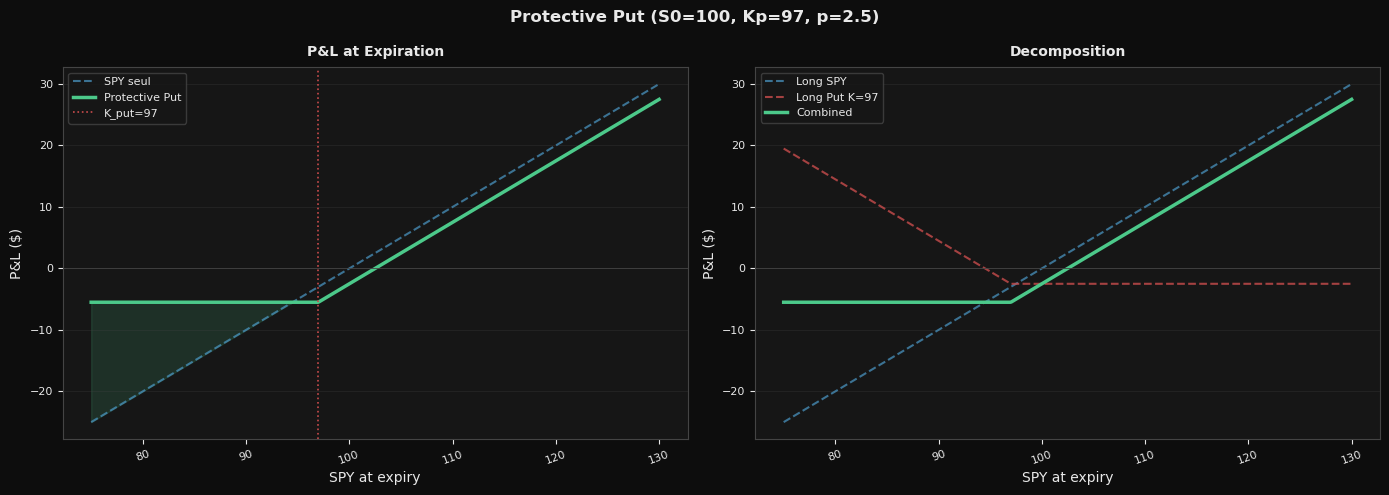

In [2]:
# Payoff diagram
fig, axes = plt.subplots(1,2,figsize=(14,5),facecolor=BG)
S0,Kp,p = 100,97,2.5
ST = np.linspace(75,130,500)
pnl_spy = ST-S0
pnl_put = np.maximum(Kp-ST,0)-p
pnl_pp  = pnl_spy+pnl_put
axes[0].plot(ST,pnl_spy,color=BLUE, lw=1.5,ls='--',label='SPY seul',alpha=0.7)
axes[0].plot(ST,pnl_pp, color=GREEN,lw=2.5,label='Protective Put')
axes[0].axvline(Kp,color=RED,lw=1.2,ls=':',label=f'K_put={Kp}')
axes[0].fill_between(ST,pnl_pp,pnl_spy,where=pnl_pp>pnl_spy,alpha=0.15,color=GREEN)
style_ax(axes[0],'P&L at Expiration'); legend(axes[0])
axes[0].set_xlabel('SPY at expiry'); axes[0].set_ylabel('P&L ($)')
axes[1].plot(ST,pnl_spy,color=BLUE,lw=1.5,ls='--',label='Long SPY',alpha=0.7)
axes[1].plot(ST,pnl_put,color=RED, lw=1.5,ls='--',label=f'Long Put K={Kp}',alpha=0.8)
axes[1].plot(ST,pnl_pp, color=GREEN,lw=2.5,label='Combined')
style_ax(axes[1],'Decomposition'); legend(axes[1])
axes[1].set_xlabel('SPY at expiry'); axes[1].set_ylabel('P&L ($)')
fig.suptitle(f'Protective Put (S0={S0}, Kp={Kp}, p={p})',color=WHITE,fontsize=12,fontweight='bold')
fig.patch.set_facecolor(BG); plt.tight_layout(); plt.show()

## 2. Strategy Construction

At each **roll date** (monthly expiration):
1. Select put with DTE≈30 and Δ≈−0.30
2. Buy at mid → `Cash -= premium`
3. At expiration: `Cash += max(K_p - S_T, 0)`

$$V_t = S_t + \text{Cash}_t + \text{Put}_{\text{MTM},t}$$

In [3]:
#DATA_PATH = '../data/spy_simulated_2020_2022.csv'
# Uncomment to use real data:
DATA_PATH = '../data/spy_2020_2022.csv'

df = load_data(DATA_PATH)
print('Data loaded:', df.shape)

✅  Loaded: ../data/spy_2020_2022.csv
    Rows            : 3,589,079
    Period          : 2020-01-02 → 2022-12-30
    Trading days    : 758
    Unique strikes  : 641
    Unique expiries : 514
Data loaded: (3589079, 35)


In [4]:
from src.strategy_protective_put import build_protective_put
pp = build_protective_put(df, target_dte=30, target_delta=-0.30)
pp[['spy_price','index_level','spy_bnh','put_strike','put_premium','put_iv']].tail(10)

✅  Protective Put index built
    Days      : 758
    Rolls     : 37
    Avg IV    : 23.84%
    Avg prem  : 5.126


,spy_price,index_level,spy_bnh,put_strike,put_premium,put_iv
date,,,,,,
2022-12-19,380.02,109.917813,116.976021,391.0,4.685,0.20861
2022-12-20,380.49,109.991689,117.120694,391.0,4.685,0.20861
2022-12-21,386.21,110.140979,118.881399,391.0,4.685,0.20861
2022-12-22,380.72,110.007080,117.191492,391.0,4.685,0.20861
2022-12-23,382.88,109.954751,117.856373,373.0,4.490,0.21085
2022-12-26,382.91,109.960907,117.865608,373.0,4.490,0.21085
2022-12-27,381.38,109.533044,117.394650,373.0,4.490,0.21085
2022-12-28,376.71,108.548035,115.957152,373.0,4.490,0.21085
2022-12-29,383.33,109.870102,117.994890,373.0,4.490,0.21085


## 3. Performance Dashboard

  Chart saved → ../outputs/chart_protective_put.png


/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/plotting.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


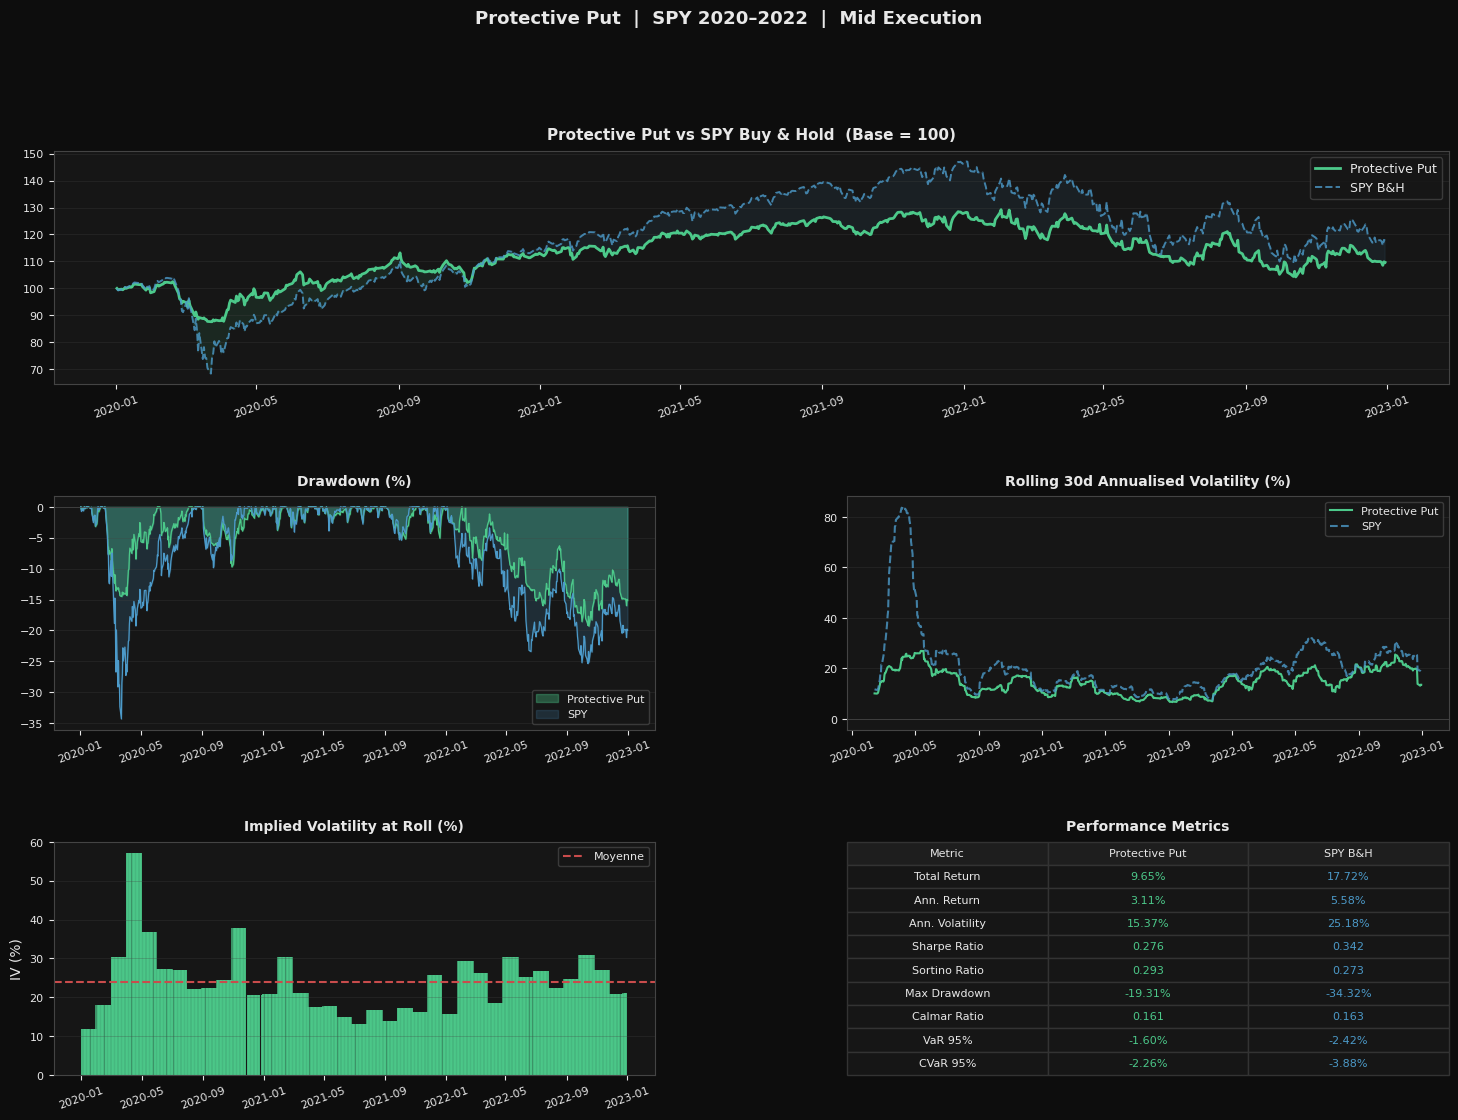

In [5]:
from src.plotting import plot_strategy_dashboard
plot_strategy_dashboard(pp, 'Protective Put', GREEN,
                        save_path='../outputs/chart_protective_put.png')

## 4. Metrics

In [ ]:
m = compute_metrics(pp)
for k,v in m.items():
    if isinstance(v,float): print(f'  {k:<25} {v:.4f}')